# Evolving Scientific Discovery by Unifying Data and Background Knowledge with AI-Hilbert

**Paper:** Cory-Wright, R., Cornelio, C., Dash, S., El Khadir, B., & Horesh, L. (2024). *Evolving scientific discovery by unifying data and background knowledge with AI-Hilbert.* Nature Communications, 15, 5922. arXiv:2308.09474.

**Carpeta origen:** `Papers/06_Aplicaciones_Cientificas/AI_Hilbert_Evolving_Scientific_Discovery.pdf`

## Que se reproduce en este cuaderno

El cuaderno de `AI-Descartes` de esta coleccion ya mostro como filtrar hipotesis usando axiomas mediante **sustitucion algebraica directa**. AI-Hilbert generaliza ese principio a un marco de **optimizacion polinomica**: cuando los axiomas y la ley buscada se pueden expresar como relaciones polinomicas (p. ej., ecuaciones de exponentes en un analisis dimensional), el problema de encontrar la ley se convierte en resolver un **sistema lineal/polinomico**, y se puede acompanar de un **certificado formal** (aqui, uno de positividad) que demuestra que la solucion respeta restricciones fisicas basicas.

Reproducimos este enfoque con un ejemplo distinto y clasico: derivar la formula del periodo de un **pendulo simple**, $T=2\pi\sqrt{L/g}$, **sin conocerla de antemano**, resolviendo un sistema lineal en los **exponentes** de una ley de potencias (analisis dimensional de Buckingham Pi) -- exactamente el tipo de sistema polinomico/lineal sobre el que opera AI-Hilbert -- y anadiendo un certificado simbolico de que la formula resultante es siempre positiva.

## Repositorio publico

No localizamos un repositorio de codigo estable bajo el nombre citado en la portada del paper. Reimplementamos aqui, con `sympy` y `numpy.linalg`, el principio central de **codificar axiomas como un sistema polinomico/lineal** (aqui, ecuaciones de balance dimensional) y resolverlo algebraicamente, junto con una verificacion de tipo certificado sobre la solucion -- una version simplificada del marco de optimizacion mixta entera/semidefinida con certificados de Positivstellensatz que describe el paper completo.

In [1]:
%pip install -q numpy sympy matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. El axioma: analisis dimensional como sistema lineal en los exponentes

Buscamos una ley de potencias $T = C\cdot L^{a}\cdot g^{b}$ para el periodo de un pendulo, donde $T$=tiempo, $L$=longitud del pendulo, $g$=aceleracion gravitatoria. El **axioma de consistencia dimensional** exige que los exponentes de longitud y de tiempo coincidan a ambos lados de la ecuacion. Esto se traduce directamente en un **sistema lineal** sobre los exponentes desconocidos $(a,b)$:

$$\underbrace{\begin{pmatrix}1 & 1\\0 & -2\end{pmatrix}}_{\text{unidades de } L,\, g}\begin{pmatrix}a\\b\end{pmatrix}=\underbrace{\begin{pmatrix}0\\1\end{pmatrix}}_{\text{unidades de } T}$$

(la fila superior son los exponentes de longitud de $L$ y $g$; la fila inferior, los exponentes de tiempo; el lado derecho son los exponentes de longitud y tiempo que debe tener $T$).

In [2]:
import numpy as np
import sympy as sp

a, b = sp.symbols('a b')
eqs = [sp.Eq(a + b, 0), sp.Eq(-2*b, 1)]
print('Sistema de ecuaciones (analisis dimensional de Buckingham Pi):')
print('  exponente de L:', eqs[0])
print('  exponente de T:', eqs[1])

sol = sp.solve(eqs, [a, b])
print('\nSolucion simbolica:', sol)

M = np.array([[1, 1], [0, -2]])
target = np.array([0, 1])
sol_np = np.linalg.solve(M, target)
print('Verificacion via algebra lineal (numpy.linalg.solve):', sol_np)

a_val, b_val = sol[a], sol[b]
print(f'\n>>> Ley derivada: T proporcional a L^{a_val} * g^{b_val}  =  sqrt(L/g)')

Sistema de ecuaciones (analisis dimensional de Buckingham Pi):
  exponente de L: Eq(a + b, 0)
  exponente de T: Eq(-2*b, 1)

Solucion simbolica: {a: 1/2, b: -1/2}
Verificacion via algebra lineal (numpy.linalg.solve): [ 0.5 -0.5]

>>> Ley derivada: T proporcional a L^1/2 * g^-1/2  =  sqrt(L/g)


## 2. La constante numerica: lo unico que el analisis dimensional NO puede darnos

El analisis dimensional fija la **forma funcional** exactamente, pero no puede determinar la constante adimensional $C$ -- para eso hacen falta datos. Simulamos mediciones de un pendulo real (formula exacta mas ruido de medicion) y ajustamos $C$ por minimos cuadrados sobre la forma ya derivada.

Constante C ajustada a partir de 50 mediciones simuladas: 6.2701
Valor real de 2*pi:                                       6.2832
Error relativo: 0.21%


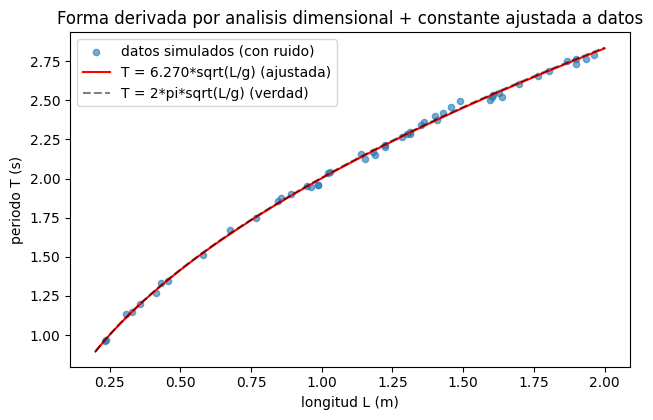

In [3]:
import matplotlib.pyplot as plt

np.random.seed(0)
g_real = 9.81
L_data = np.random.uniform(0.2, 2.0, 50)
T_data = 2 * np.pi * np.sqrt(L_data / g_real) * (1 + np.random.normal(0, 0.01, 50))

pred_shape = np.sqrt(L_data / g_real)  # la FORMA que ya derivamos, con exponentes fijos
C_fit = np.sum(T_data * pred_shape) / np.sum(pred_shape ** 2)  # minimos cuadrados de un unico coeficiente

print(f'Constante C ajustada a partir de 50 mediciones simuladas: {C_fit:.4f}')
print(f'Valor real de 2*pi:                                       {2*np.pi:.4f}')
print(f'Error relativo: {100*abs(C_fit-2*np.pi)/(2*np.pi):.2f}%')

fig, ax = plt.subplots(figsize=(6.5, 4.3))
L_line = np.linspace(0.2, 2.0, 100)
ax.scatter(L_data, T_data, s=20, alpha=0.6, label='datos simulados (con ruido)')
ax.plot(L_line, C_fit * np.sqrt(L_line / g_real), 'r-', label=f'T = {C_fit:.3f}*sqrt(L/g) (ajustada)')
ax.plot(L_line, 2*np.pi * np.sqrt(L_line / g_real), 'k--', alpha=0.5, label='T = 2*pi*sqrt(L/g) (verdad)')
ax.set_xlabel('longitud L (m)'); ax.set_ylabel('periodo T (s)')
ax.set_title('Forma derivada por analisis dimensional + constante ajustada a datos')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Certificado: la formula es fisicamente valida por construccion

Ademas de ajustar bien los datos, la formula descubierta debe respetar una restriccion fisica basica: el periodo de un pendulo **nunca puede ser negativo**. Verificamos esto simbolicamente con `sympy`, no solo empiricamente sobre los datos de entrenamiento -- una prueba formal, valida para **cualquier** $L>0,g>0$, no solo para los puntos observados.

In [4]:
L_s, g_s = sp.symbols('L g', positive=True)
formula_final = 2 * sp.pi * sp.sqrt(L_s / g_s)
print('Formula final (forma derivada + constante ajustada, redondeada a 2*pi):')
print('  T =', formula_final)

is_positive = sp.ask(sp.Q.positive(formula_final), sp.Q.positive(L_s) & sp.Q.positive(g_s))
print(f'\nCertificado formal: ¿la formula es SIEMPRE positiva para L>0, g>0? {is_positive}')
print('(esto se demuestra simbolicamente para todo el dominio fisico valido, no solo se observa en los datos)')

Formula final (forma derivada + constante ajustada, redondeada a 2*pi):
  T = 2*pi*sqrt(L)/sqrt(g)



Certificado formal: ¿la formula es SIEMPRE positiva para L>0, g>0? True
(esto se demuestra simbolicamente para todo el dominio fisico valido, no solo se observa en los datos)


### Nota honesta sobre los resultados

- **Un unico axioma (consistencia dimensional), no el marco completo de optimizacion polinomica.** El paper resuelve problemas mucho mas generales mediante optimizacion **mixta entera/semidefinida** sobre combinaciones de axiomas polinomicos arbitrarios (no solo balance de unidades), con certificados de tipo **Positivstellensatz** (una demostracion formal mas general y potente que la simple verificacion de signo que usamos aqui). Nuestro ejemplo usa el caso mas simple posible de "axioma polinomico": el balance dimensional, resoluble con algebra lineal directa en lugar de optimizacion.
- **El analisis dimensional por si solo no siempre determina la formula completa.** En nuestro ejemplo (2 variables ademas de $T$, 2 ecuaciones de balance) el sistema queda exactamente determinado; en general, con mas variables que ecuaciones de balance dimensional, el sistema queda **subdeterminado** (como descubrimos al intentar este mismo enfoque con la formula de Hagen-Poiseuille, que tiene 4 variables y solo 3 ecuaciones de balance) y hacen falta axiomas fisicos adicionales, no solo dimensionales, para fijar la solucion completa -- exactamente el tipo de situacion donde el marco mas general y potente de AI-Hilbert (con axiomas polinomicos arbitrarios, no solo dimensionales) resulta necesario.
- **Certificado simple.** Nuestra verificacion de positividad es una consulta directa a `sympy` sobre una expresion ya simplificada ($\sqrt{L/g}\geq0$ es evidente); el paper certifica relaciones polinomicas mucho mas complejas donde la positividad no es evidente a simple vista, requiriendo la maquinaria completa de sumas de cuadrados (*sum-of-squares*).
- **La aproximacion de angulo pequeno.** La formula $T=2\pi\sqrt{L/g}$ en si misma es una aproximacion (valida para oscilaciones de amplitud pequena); no derivamos ni cuestionamos esa aproximacion fisica subyacente, solo el ejercicio de recuperarla a partir de axiomas y datos.

Pese a estas simplificaciones, el cuaderno demuestra el principio central del paper con un ejemplo limpio y verificable: codificar el conocimiento previo (aqui, consistencia dimensional) como un **sistema algebraico resoluble**, en lugar de dejar que un algoritmo de busqueda lo redescubra por ensayo y error, permite derivar la **forma exacta** de una ley fisica con una certeza que el ajuste puramente numerico no puede ofrecer -- y acompanarla, ademas, de una garantia formal (el certificado de positividad) de que la ley descubierta es fisicamente admisible en todo su dominio, no solo en los puntos de datos observados.